In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import joblib
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, classification_report


# 1. Random forest på hela datan

In [60]:
pred = pd.read_csv("../results/rf_mc_balanced_val/unseen_predictions.csv")
pred.groupby("y_true")["y_proba"].describe()

,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,69.0,0.164972,0.089690,0.035195,0.092821,0.143937,0.222803,0.447438
1,13.0,0.192042,0.084028,0.056361,0.150574,0.167084,0.228836,0.356737


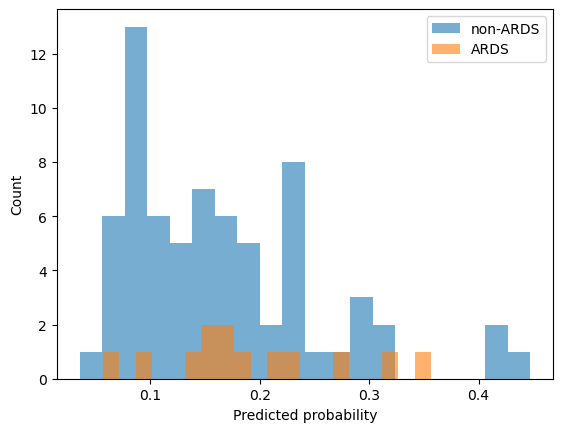

In [61]:
plt.hist(pred.loc[pred["y_true"] == 0, "y_proba"], bins=20, alpha=0.6, label="non-ARDS")
plt.hist(pred.loc[pred["y_true"] == 1, "y_proba"], bins=20, alpha=0.6, label="ARDS")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

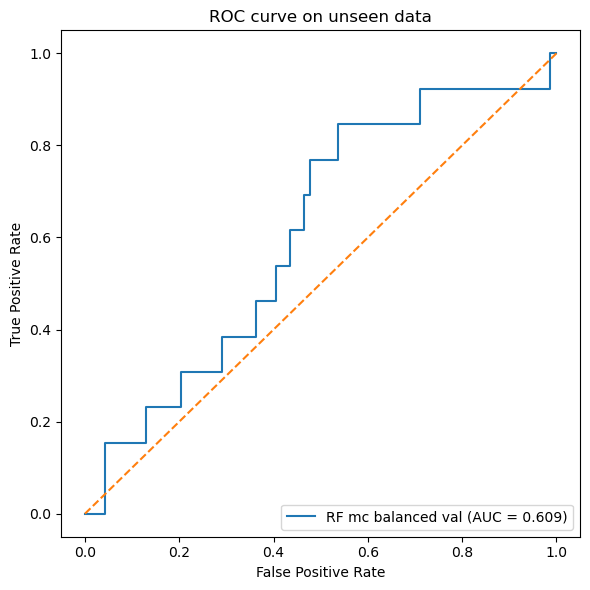

In [62]:
results_dir = Path("../results/rf_mc_balanced_val")  # ändra vid behov

model = joblib.load(results_dir / "final_model.joblib")
unseen = pd.read_csv(results_dir / "unseen.csv")

protein_cols = [c for c in unseen.columns if c.startswith("seq.")]
X_unseen = unseen[protein_cols].copy()
y_unseen = unseen["ards"].astype(int).copy()

y_proba = model.predict_proba(X_unseen)[:, 1]
auc = roc_auc_score(y_unseen, y_proba)
fpr, tpr, thresholds = roc_curve(y_unseen, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF mc balanced val (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on unseen data")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [63]:
# =========================================
# Prediktioner (threshold = 0.5)
# =========================================
y_pred = (y_proba >= 0.5).astype(int)

# =========================================
# Confusion matrix
# =========================================
cm = confusion_matrix(y_unseen, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nFormatted:")
print(f"TN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")

# =========================================
# F1 score
# =========================================
f1 = f1_score(y_unseen, y_pred)

print(f"\nF1 score (ARDS=1): {f1:.3f}")

Confusion Matrix:
[[69  0]
 [13  0]]

Formatted:
TN: 69, FP: 0
FN: 13, TP: 0

F1 score (ARDS=1): 0.000


# 2. Random Forest på 60 feature proteiner

In [64]:
# Ladda
ttest = pd.read_csv("../results/ttest/filtered_data/selected_features_k20.csv")
mi    = pd.read_csv("../results/mi_uni_test/selected_features_k20.csv")
fs    = pd.read_csv("../results/fs/selected_features_n_features20.csv")

def get_feature_col(df):
    for c in ["protein", "Protein", "feature", "Feature", "selected_feature"]:
        if c in df.columns:
            return c
    return df.columns[0]

f_ttest = set(ttest[get_feature_col(ttest)])
f_mi    = set(mi[get_feature_col(mi)])
f_fs    = set(fs[get_feature_col(fs)])

# Union
union_features = sorted(list(f_ttest | f_mi | f_fs))

print("Antal features:", len(union_features))

Antal features: 59


In [65]:
df = pd.read_csv("../data/processed/filtered_data.csv")

cols = union_features + ["ards"]
df_small = df[cols]

df_small.to_csv("../data/processed/filtered_data_top60.csv", index=False)

/var/folders/rz/3cfhhdrd2bs65msqx2gtqcph0000gn/T/ipykernel_23104/2248686275.py:1: DtypeWarning: Columns (10818,10820) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/filtered_data.csv")


In [66]:
pred_top60 = pd.read_csv("../results/rf_top60/unseen_predictions.csv")
pred_top60.groupby("y_true")["y_proba"].describe()

,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,69.0,0.185904,0.149958,0.023524,0.069595,0.145627,0.253364,0.717695
1,13.0,0.305931,0.175145,0.047564,0.176462,0.318667,0.428642,0.614468


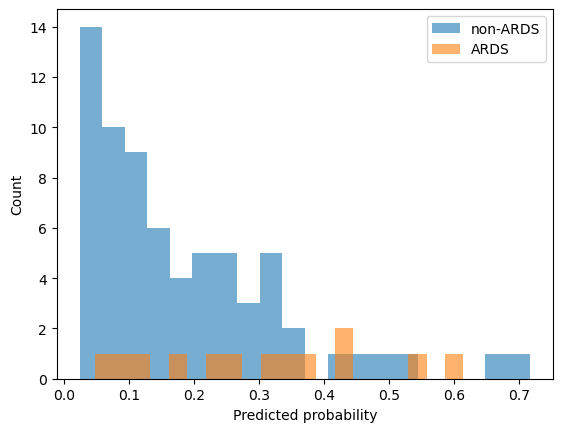

In [67]:
plt.hist(pred_top60.loc[pred_top60["y_true"] == 0, "y_proba"], bins=20, alpha=0.6, label="non-ARDS")
plt.hist(pred_top60.loc[pred_top60["y_true"] == 1, "y_proba"], bins=20, alpha=0.6, label="ARDS")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

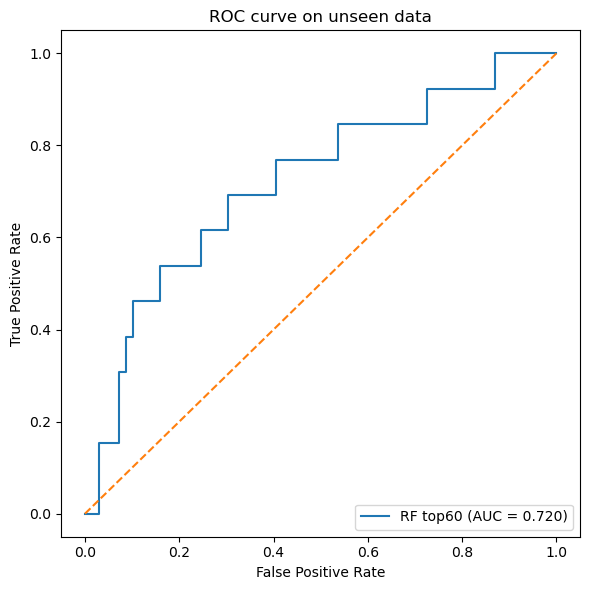

In [68]:
results_dir = Path("../results/rf_top60")  # ändra vid behov

model = joblib.load(results_dir / "final_model.joblib")
unseen = pd.read_csv(results_dir / "unseen.csv")

protein_cols = [c for c in unseen.columns if c.startswith("seq.")]
X_unseen = unseen[protein_cols].copy()
y_unseen = unseen["ards"].astype(int).copy()

y_proba = model.predict_proba(X_unseen)[:, 1]
auc = roc_auc_score(y_unseen, y_proba)
fpr, tpr, thresholds = roc_curve(y_unseen, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF top60 (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on unseen data")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [69]:
# =========================================
# Prediktioner (threshold = 0.5)
# =========================================
y_pred = (y_proba >= 0.5).astype(int)

# =========================================
# Confusion matrix
# =========================================
cm = confusion_matrix(y_unseen, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nFormatted:")
print(f"TN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")

# =========================================
# F1 score
# =========================================
f1 = f1_score(y_unseen, y_pred)

print(f"\nF1 score (ARDS=1): {f1:.3f}")

Confusion Matrix:
[[66  3]
 [11  2]]

Formatted:
TN: 66, FP: 3
FN: 11, TP: 2

F1 score (ARDS=1): 0.222


# 3. Random Forest på större grid top60 proteiner

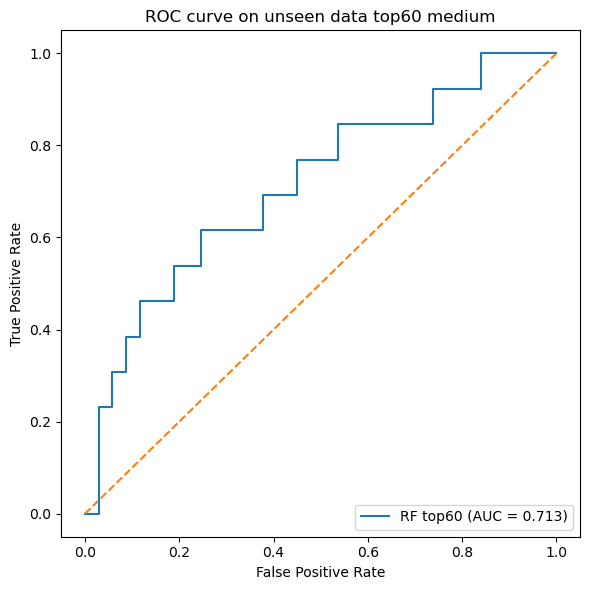

In [93]:
results_dir = Path("../results/rf_top60_medium")  # ändra vid behov

model = joblib.load(results_dir / "final_model.joblib")
unseen = pd.read_csv(results_dir / "unseen.csv")

protein_cols = [c for c in unseen.columns if c.startswith("seq.")]
X_unseen = unseen[protein_cols].copy()
y_unseen = unseen["ards"].astype(int).copy()

y_proba = model.predict_proba(X_unseen)[:, 1]
auc = roc_auc_score(y_unseen, y_proba)
fpr, tpr, thresholds = roc_curve(y_unseen, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"RF top60 (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on unseen data top60 medium")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [94]:
predmed = pd.read_csv("../results/rf_top60_medium/unseen_predictions.csv")
predmed.groupby("y_true")["y_proba"].describe()

,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,69.0,0.214208,0.158540,0.030544,0.071382,0.165645,0.295589,0.709299
1,13.0,0.348672,0.195026,0.059172,0.188195,0.352310,0.480596,0.614672


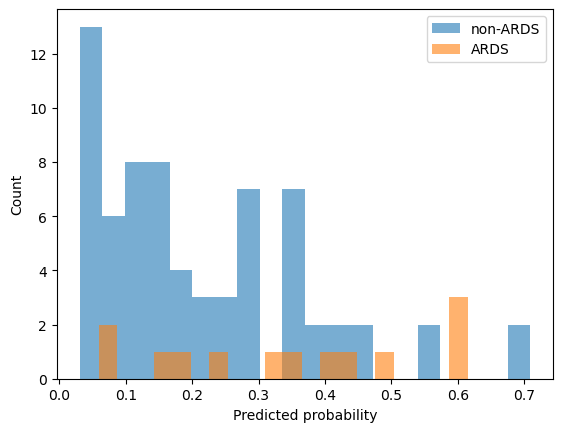

In [95]:
plt.hist(predmed.loc[predmed["y_true"] == 0, "y_proba"], bins=20, alpha=0.6, label="non-ARDS")
plt.hist(predmed.loc[predmed["y_true"] == 1, "y_proba"], bins=20, alpha=0.6, label="ARDS")
plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

In [96]:
# =========================================
# Prediktioner (threshold = 0.5)
# =========================================
y_pred = (y_proba >= 0.5).astype(int)

# =========================================
# Confusion matrix
# =========================================
cm = confusion_matrix(y_unseen, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nFormatted:")
print(f"TN: {tn}, FP: {fp}")
print(f"FN: {fn}, TP: {tp}")

# =========================================
# F1 score
# =========================================
f1 = f1_score(y_unseen, y_pred)

print(f"\nF1 score (ARDS=1): {f1:.3f}")

Confusion Matrix:
[[65  4]
 [10  3]]

Formatted:
TN: 65, FP: 4
FN: 10, TP: 3

F1 score (ARDS=1): 0.300


In [97]:
print("\nClassification report:")
print(classification_report(y_unseen, y_pred, digits=3))


Classification report:
              precision    recall  f1-score   support

           0      0.867     0.942     0.903        69
           1      0.429     0.231     0.300        13

    accuracy                          0.829        82
   macro avg      0.648     0.586     0.601        82
weighted avg      0.797     0.829     0.807        82



In [99]:
# Feature importance and shap values

rf = model.named_steps["rf"]

feat_imp_df = pd.DataFrame({
    "Protein": protein_cols,
    "rf_importance": rf.feature_importances_
}).sort_values("rf_importance", ascending=False)

feat_imp_df.head(20)

,Protein,rf_importance
29,seq.26102.249,0.063925
22,seq.23224.11,0.055962
49,seq.34205.12,0.049344
38,seq.31598.17,0.037043
3,seq.12351.25,0.034912
30,seq.26103.20,0.032320
57,seq.8699.43,0.027353
9,seq.17725.37,0.027127
40,seq.31740.27,0.025020
32,seq.27115.9,0.024552


In [105]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_unseen)

# Handle SHAP output differences across versions/model types
if isinstance(shap_values, list):
    # Older API often returns one array per class
    shap_vals_ards = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    sv = np.asarray(shap_values)
    if sv.ndim == 3:
        # Expected shape: (n_samples, n_features, n_classes)
        class_idx = 1 if sv.shape[2] > 1 else 0
        shap_vals_ards = sv[:, :, class_idx]
    elif sv.ndim == 2:
        # Expected shape: (n_samples, n_features)
        shap_vals_ards = sv
    else:
        raise ValueError(f"Unexpected SHAP shape: {sv.shape}")

mean_abs_shap = np.abs(shap_vals_ards).mean(axis=0)

# Safety check to catch shape mismatches early
if len(mean_abs_shap) != len(protein_cols):
    raise ValueError(
        f"Length mismatch: mean_abs_shap={len(mean_abs_shap)} vs protein_cols={len(protein_cols)}"
    )

shap_importance_df = pd.DataFrame({
    "Protein": protein_cols,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

shap_importance_df.head(20)

,Protein,mean_abs_shap
29,seq.26102.249,0.037619
22,seq.23224.11,0.030098
49,seq.34205.12,0.028314
38,seq.31598.17,0.024158
3,seq.12351.25,0.019879
30,seq.26103.20,0.014762
9,seq.17725.37,0.014469
57,seq.8699.43,0.014404
17,seq.21184.1,0.013608
8,seq.17456.53,0.013604


# Kolla bästa modellen på hyperparameterarna

In [86]:
all_runs = pd.read_csv("../results/rf_top60_medium/all_runs.csv")

In [87]:
df = all_runs.copy()

import ast

def to_matrix(cm):
    if isinstance(cm, str):
        cm = ast.literal_eval(cm)   # convert string -> list
    return np.array(cm)

# Convert and extract 4th value (bottom-right)
df["cm_arr"] = df["confusion_matrix"].apply(to_matrix)
df["fourth_value"] = df["cm_arr"].apply(lambda cm: cm[1, 1])

# Largest 4th value
max_fourth = df["fourth_value"].max()

# All rows tied for largest
best_rows = df[df["fourth_value"] == max_fourth]

print("Largest 4th value:", max_fourth)
print("Rows with largest 4th value:", best_rows.index.tolist())
print("\nConfusion matrices at those rows:")
print(best_rows["confusion_matrix"])

# Position(s) of value 1 in each best matrix
for idx, cm in best_rows["cm_arr"].items():
    ones_pos = np.argwhere(cm == 1)  # zero-based positions
    print(f"Row {idx}, positions of 1s (row, col): {ones_pos.tolist()}")

Largest 4th value: 9
Rows with largest 4th value: [2992, 2996, 3112, 3116, 3232, 3236]

Confusion matrices at those rows:
2992    [[15, 1], [7, 9]]
2996    [[15, 1], [7, 9]]
3112    [[15, 1], [7, 9]]
3116    [[15, 1], [7, 9]]
3232    [[15, 1], [7, 9]]
3236    [[15, 1], [7, 9]]
Name: confusion_matrix, dtype: object
Row 2992, positions of 1s (row, col): [[0, 1]]
Row 2996, positions of 1s (row, col): [[0, 1]]
Row 3112, positions of 1s (row, col): [[0, 1]]
Row 3116, positions of 1s (row, col): [[0, 1]]
Row 3232, positions of 1s (row, col): [[0, 1]]
Row 3236, positions of 1s (row, col): [[0, 1]]


In [92]:
# Show all original columns from all_runs for the best rows
best_rows_all_columns = all_runs.loc[best_rows.index]
display(best_rows_all_columns)

# If you want to exclude helper columns from df:
cols_to_exclude = ["cm_arr", "fourth_value"]
other_cols = [c for c in df.columns if c not in cols_to_exclude]
display(best_rows[other_cols])

,split_id,split_seed,n_train,n_val,n_ards_train,n_ards_val,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,roc_auc,pr_auc,balanced_accuracy,recall_ards,precision_ards,f1_ards,specificity,prevalence_ards,confusion_matrix
2992,8,50,294,32,36,16,NaN,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
2996,8,50,294,32,36,16,NaN,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3112,8,50,294,32,36,16,10.0,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3116,8,50,294,32,36,16,10.0,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3232,8,50,294,32,36,16,20.0,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3236,8,50,294,32,36,16,20.0,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"


,split_id,split_seed,n_train,n_val,n_ards_train,n_ards_val,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,roc_auc,pr_auc,balanced_accuracy,recall_ards,precision_ards,f1_ards,specificity,prevalence_ards,confusion_matrix
2992,8,50,294,32,36,16,NaN,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
2996,8,50,294,32,36,16,NaN,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3112,8,50,294,32,36,16,10.0,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3116,8,50,294,32,36,16,10.0,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3232,8,50,294,32,36,16,20.0,0.2,15,2,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
3236,8,50,294,32,36,16,20.0,0.2,15,10,300,0.886719,0.880344,0.75,0.5625,0.9,0.692308,0.9375,0.5,"[[15, 1], [7, 9]]"
